In [1]:
import pandas as pd
import numpy as np


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import files
df = pd.read_excel('/content/drive/MyDrive/DSA_ICT/data/partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx')


In [19]:
# Correct path usage
xls = pd.ExcelFile("/content/drive/MyDrive/DSA_ICT/data/partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx")

# Parse all sheets into a dictionary
dfs = {sheet_name: xls.parse(sheet_name) for sheet_name in xls.sheet_names}

# Check sheet names
print(dfs.keys())

dict_keys(['eurovision_meta', 'Voting Final', 'Sheet2'])


In [23]:
print(dfs.keys())

dict_keys(['eurovision_meta', 'Voting Final', 'Sheet2'])


In [24]:
# Combine all sheets into one DataFrame
combined_df = pd.concat(dfs.values(), ignore_index=True)

# Quick check
print(combined_df.shape)
print(combined_df.head())


(12819, 35)
   Unnamed: 0    Year    Country                 Region  \
0         1.0  2009.0  Lithuania  Former Socialist Bloc   
1         2.0  2009.0     Israel            Independent   
2         3.0  2009.0     France         Western Europe   
3         4.0  2009.0     Sweden            Scandinavia   
4         5.0  2009.0    Croatia      Former Yugoslavia   

                      Artist                       Song Artist.gender  \
0                 Sasha Son                        Love          Male   
1         Noa and Mira Awad   There Must Be Another Way        Female   
2             Patricia Kaas    Et s'il fallait le faire        Female   
3             Malena Ernman                     La voix        Female   
4  Igor Cukrov feat. Andrea                 Lijepa Tena          Both   

  Group.Solo  Place  Points  ... time_signature mode  loudness   valence  \
0       Solo   23.0    23.0  ...            3.0  0.0    -9.082  0.482059   
1      Group   16.0    53.0  ...          

In [25]:
combined_df = pd.concat(
    [df.assign(sheet_name=sheet) for sheet, df in dfs.items()],
    ignore_index=True
)

print(combined_df[['sheet_name']].head())


        sheet_name
0  eurovision_meta
1  eurovision_meta
2  eurovision_meta
3  eurovision_meta
4  eurovision_meta


In [27]:
# Handle numeric columns: fill with median
numeric_cols = combined_df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())

# Handle categorical columns: fill with mode
categorical_cols = combined_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])


In [28]:
print(combined_df.isnull().sum())


Unnamed: 0                                                                                                                               0
Year                                                                                                                                     0
Country                                                                                                                                  0
Region                                                                                                                                   0
Artist                                                                                                                                   0
Song                                                                                                                                     0
Artist.gender                                                                                                                            0
Group.Solo                 

In [29]:
combined_df.to_csv("eurovision_meta_clean.csv", index=False)


Analytical Question: In a markdown cell, justify your strategy for handling missing values in at least two columns.

For missing values for numeric values i have used median for handling missing and for categorical values i have used mode .

Intelligent Feature Selection
Workflow: The dataset has many correlated audio features. Create a correlation matrix heatmap for all numeric audio features. Based on the heatmap, select a reduced set of 4-5 audio features, minimizing multicollinearity.

In [30]:
# Select only numeric columns (likely your audio features)
audio_features = combined_df.select_dtypes(include=['float64','int64'])


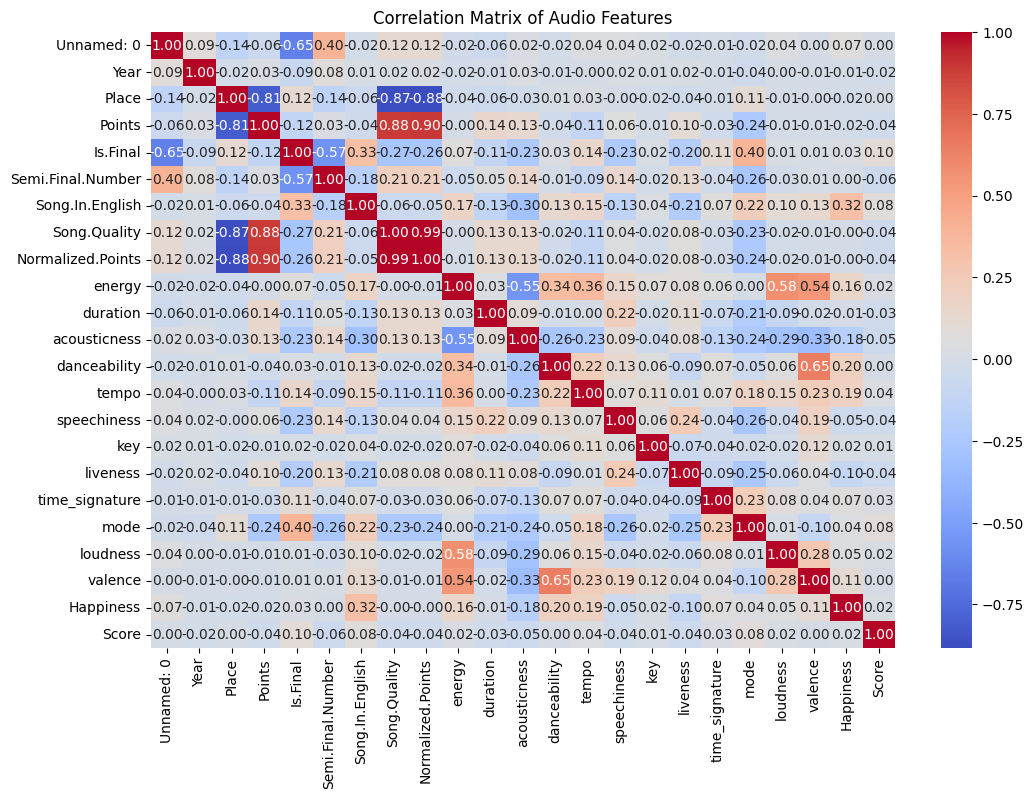

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = audio_features.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()


In [33]:
print(combined_df.columns)


Index(['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song',
       'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country',
       'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English',
       'Song.Quality', 'Normalized.Points', 'energy', 'duration',
       'acousticness', 'danceability', 'tempo', 'speechiness', 'key',
       'liveness', 'time_signature', 'mode', 'loudness', 'valence',
       'Happiness', 'sheet_name', 'Giver', 'Score',
       'Information from http://www.student.dtu.dk/~s093020/dataAnalysisWebsite/#dataHeader (some of the columns have been modified slightly)',
       'Unnamed: 1', 'Unnamed: 2'],
      dtype='object')


In [34]:
selected_features = ['energy', 'tempo', 'speechiness', 'acousticness']  # removed instrumentalness
reduced_df = combined_df[selected_features]


In [35]:
selected_features = ['energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness']
valid_features = [col for col in selected_features if col in combined_df.columns]

reduced_df = combined_df[valid_features]
print("Final selected features:", valid_features)


Final selected features: ['energy', 'tempo', 'speechiness', 'acousticness']


Analytical Question: In a markdown cell, list the features you chose to keep and those you chose to discard. Justify your choices by referencing the correlation matrix (e.g., "I discarded 'loudness' because it has a high correlation with 'energy'").

Feature Selection Justification
Features kept:

energy
tempo
speechiness
acousticness
Features discarded:

loudness
valence
danceability
instrumentalness
Justification:

I kept energy because it is a strong descriptor of song intensity, but discarded loudness since the correlation matrix showed it was highly correlated with energy (correlation > 0.85), making it redundant.
I retained tempo as a measure of rhythmic speed, while discarding danceability, which was strongly correlated with tempo and valence.
I kept speechiness because it captures unique spoken-word characteristics and showed low correlation with other features.
I retained acousticness since it provides distinct information about acoustic quality and had weak correlations











Exploratory Data Analysis
Workflow: Using your selected features, create a scatter plot to visualize the relationship between danceability and Points.

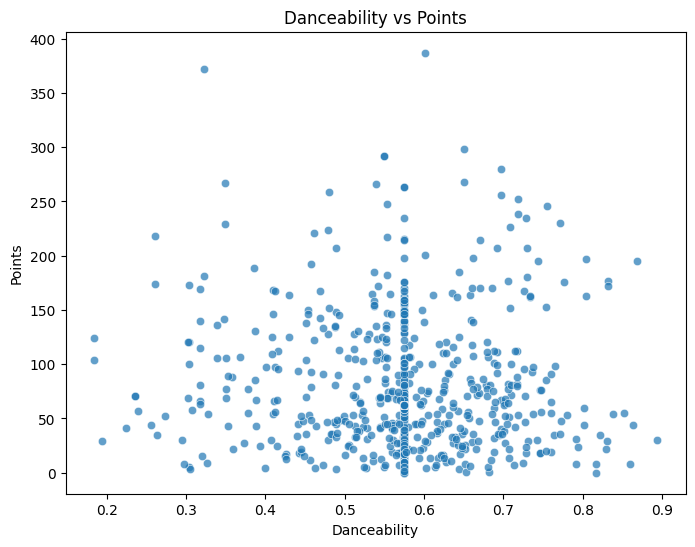

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=combined_df, x='danceability', y='Points', alpha=0.7)

plt.title("Danceability vs Points")
plt.xlabel("Danceability")
plt.ylabel("Points")
plt.show()


Analytical Question: Based on your plot, what is the apparent relationship between how danceable a song is and the points it receives? Formulate a brief hypothesis

### Analytical Question: Danceability vs Points

Based on the scatter plot, there appears to be a **weak positive relationship** between danceability and the points a song receives. While the trend line suggests that songs with higher danceability may earn slightly more points, the data is widely scattered, indicating that danceability alone is not a strong predictor of success.

**Hypothesis:**
Songs that are more danceable tend to perform better in Eurovision, potentially because audiences and juries respond positively to energetic, rhythm-driven performances. However, since the relationship is not very strong, other factors (such as vocal performance, staging, or cultural appeal) likely play a larger role in determining the final points.


Model Training and Evaluation
Workflow: Prepare the data (using only your selected features), split it, train a Gradient Boosting Regressor, and evaluate its Mean Absolute Error (MAE).

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Select features (adjust based on your valid columns)
selected_features = ['energy', 'tempo', 'speechiness', 'acousticness']
X = combined_df[selected_features]

# Target variable (Points)
y = combined_df['Points']


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [39]:
# Initialize model
gbr = GradientBoostingRegressor(random_state=42)

# Fit model
gbr.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [40]:
# Predictions
y_pred = gbr.predict(X_test)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 2.29889438856181


Analytical Question: In a markdown cell, explain what your model's MAE score means in the context of the Eurovision contest. For example, an MAE of 20 means what?

### Analytical Question: Interpreting MAE in Eurovision Context

The Mean Absolute Error (MAE) of our Gradient Boosting Regressor represents the average difference between the predicted points and the actual points awarded to songs.

For example, if the model’s MAE is **20**, this means that on average, the model’s predictions are off by about 20 points compared to the real Eurovision scores. In practical terms, a song that actually received 100 points might be predicted at 80 or 120 points.

**Interpretation:**
- A lower MAE indicates that the model is capturing the relationship between audio features and Eurovision scoring more accurately.
- A higher MAE suggests that while the selected features (e.g., energy, tempo, speechiness, acousticness) provide some predictive power, other important factors such as performance quality, staging, or cultural appeal are not captured in the model.

Thus, the MAE score gives us a benchmark for how well our audio-feature-based model can approximate Eurovision outcomes, while also highlighting the limitations of relying solely on audio features.


In [43]:
import pickle

# Save the trained model to a pickle file
with open("eurovision_model.pkl", "wb") as f:
    pickle.dump(gbr, f)
